In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import os

print("🚀 BẮT ĐẦU MÔ PHỎNG PREDICTIVE AUTOSCALING CHO NASA WORKLOAD...")

# Cấu hình hằng số
TAU_SLO = 200  # Ngưỡng SLO (ms)
K_BEST = 10    # Số lượng biến trễ tối ưu cho nasa Workload

🚀 BẮT ĐẦU MÔ PHỎNG PREDICTIVE AUTOSCALING CHO NASA WORKLOAD...


Load Model và Đọc dữ liệu tập Test

In [2]:
print("📂 ĐANG LOAD MODEL VÀ DỮ LIỆU...")

# 1. Load model dự đoán tải từ Phần IV.D (Linear Regression, k=30)
try:
    forecasting_model = joblib.load(r'D:\LuanVan\prediction\workload_generation_and_forecasting\workload_forecasting\model\worldcup_en_k10.pkl')
    print("-> Đã load thành công model dự báo tải (IV.D).")
except Exception as e:
    print(f"❌ Lỗi load model dự báo tải: {e}")

# 2. Load model quyết định/ánh xạ số lượng VM từ Phần IV.C (DecisionTreeRegressor - 2 features)
try:
    scaling_model = joblib.load(r'D:\LuanVan\prediction\learning_predictive_autoscaling_policies_model\model\predictive_autoscaling_model_M_1.pkl')
    print("-> Đã load thành công model quyết định VM (IV.C).")
except Exception as e:
    print(f"❌ Lỗi load model scaling: {e}")

# 3. Đọc file dữ liệu tập test
try:
    original_df = pd.read_csv('../../workload_generation_and_forecasting/workload_generation/data/worldcup_workload.csv')
    print("-> Đã đọc file 'worldcup_workload.csv' thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn!")
    original_df = None

📂 ĐANG LOAD MODEL VÀ DỮ LIỆU...
-> Đã load thành công model dự báo tải (IV.D).
-> Đã load thành công model quyết định VM (IV.C).
-> Đã đọc file 'worldcup_workload.csv' thành công.


Chạy vòng lặp mô phỏng Algorithm 2 (Predictive Autoscaling)

In [3]:
# Chạy vòng lặp mô phỏng Algorithm 2 (Predictive Autoscaling)
if original_df is not None:
    current_vms = 1  # Đại diện cho tập tài nguyên hiện tại |V| ban đầu
    predictive_logs = []

    print("🔄 ĐANG CHẠY MÔ PHỎNG VÒNG LẶP PREDICTIVE (BÁM SÁT ALGORITHM 2)...")

    # Giả lập vòng lặp mô phỏng qua từng phút
    for idx, row in original_df.iterrows():
        current_time = int(row['time'])
        w_t = row['requests']  # Request thực tế tại thời điểm t
        
        # Lấy lát cắt 30 giá trị quá khứ ngay trước current_time từ DataFrame gốc
        historical_slice = original_df[(original_df['time'] >= current_time - K_BEST) & (original_df['time'] < current_time)]['requests'].values
        
        # CHỈ THỰC HIỆN DỰ ĐOÁN KHI ĐÃ ĐỦ K_BEST GIÁ TRỊ (BỎ QUA CÁC PHÚT ĐẦU)
        if len(historical_slice) == K_BEST:
            past_lags_ordered = historical_slice[::-1]
            
            # 1. Dự đoán tải (w_hat)
            try:
                features_dict = {}
                for i, val in enumerate(past_lags_ordered, 1):
                    features_dict[f'lag_{i}'] = [val]
                features_prediction = pd.DataFrame(features_dict)
                predicted_w = forecasting_model.predict(features_prediction)[0]
            except Exception:
                past_window_values = past_lags_ordered.reshape(1, -1)
                predicted_w = forecasting_model.predict(past_window_values)[0]

            predicted_w = max(0, predicted_w)

            # 2. Ánh xạ số lượng VM mục tiêu (c) từ mô hình M
            try:
                features_input = np.array([[predicted_w, TAU_SLO]])
                desired_vms = int(scaling_model.predict(features_input)[0])
            except Exception:
                features_df = pd.DataFrame([[predicted_w, TAU_SLO]], columns=["requests", "slo_threshold"])
                desired_vms = int(scaling_model.predict(features_df)[0])
            
            desired_vms = max(1, desired_vms) # Đảm bảo luôn có ít nhất 1 VM (c >= 1)

            # ---------------------------------------------------------
            # 3. LOGIC SO SÁNH TÀI NGUYÊN CHUẨN ALGORITHM 2
            # So sánh tài nguyên hiện tại (|V|) và VM dự kiến (c)
            # ---------------------------------------------------------
            if current_vms < desired_vms:
                # Scale-out: Cấp phát thêm (c - |V|) VMs
                added_vms = desired_vms - current_vms
                # print(f"Phút {current_time}: Scale-out thêm {added_vms} VMs (Từ {current_vms} lên {desired_vms})")
                current_vms += added_vms
                
            elif current_vms > desired_vms:
                # Scale-in: Thu hồi bớt (|V| - c) VMs
                removed_vms = current_vms - desired_vms
                # print(f"Phút {current_time}: Scale-in thu hồi {removed_vms} VMs (Từ {current_vms} xuống {desired_vms})")
                current_vms -= removed_vms
                
            else:
                # Giữ nguyên nếu |V| == c
                pass 
            # ---------------------------------------------------------
            
        else:
            # Giai đoạn warm-up (chưa đủ K_BEST mẫu): gán tải dự đoán bằng actual và giữ VM mặc định
            predicted_w = w_t
            desired_vms = 1
            current_vms = 1

        # Tính toán thời gian phản hồi thực tế
        A_PARAM, B_PARAM, C_PARAM = 8.24018, -0.0003632, -47.27967
        n_t = w_t / current_vms if current_vms > 0 else w_t
        r_t = A_PARAM * np.exp(-B_PARAM * n_t) + C_PARAM
        r_t = max(10, r_t)

        # Chỉ ghi nhận log từ phút thứ K_BEST trở đi
        predictive_logs.append({
            "minute": current_time,
            "actual_requests": w_t,
            "predicted_requests": predicted_w,
            "response_time": r_t,
            "vms_count": current_vms
        })
    df_predictive = pd.DataFrame(predictive_logs)
    os.makedirs('data', exist_ok=True)
    df_predictive.to_csv("data/worldcup_predictive.csv", index=False)
    print("✅ Đã lưu file kết quả mô phỏng worldcup thành công!")

    # Tạo DataFrame so sánh giữa Tải Thực Tế và Tải Dự Đoán
    comparison_df = pd.DataFrame({
        'Thời gian (Phút)': df_predictive['minute'], 
        'Tải Thực Tế (Actual)': df_predictive['actual_requests'], 
        'Tải Dự Đoán (Predicted)': df_predictive['predicted_requests']
    })
    comparison_df['Độ Lệch (Requests)'] = abs(comparison_df['Tải Thực Tế (Actual)'] - comparison_df['Tải Dự Đoán (Predicted)'])
    print("\n--- BẢNG SO SÁNH (15 DÒNG CUỐI) ---")
    print(comparison_df.tail(15).to_string(index=False))

🔄 ĐANG CHẠY MÔ PHỎNG VÒNG LẶP PREDICTIVE (BÁM SÁT ALGORITHM 2)...
✅ Đã lưu file kết quả mô phỏng worldcup thành công!

--- BẢNG SO SÁNH (15 DÒNG CUỐI) ---
 Thời gian (Phút)  Tải Thực Tế (Actual)  Tải Dự Đoán (Predicted)  Độ Lệch (Requests)
               73                 78575             95099.412160        16524.412160
               74                125558             75916.608862        49641.391138
               75                 64648            180393.662563       115745.662563
               76                 40346             51880.270320        11534.270320
               77                 30654             61340.544626        30686.544626
               78                 25120             47305.764573        22185.764573
               79                 16708             20067.785244         3359.785244
               80                 12429             35204.950627        22775.950627
               81                 16352             59004.553377        42652.55

c:\Users\nguye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\nguye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\nguye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\nguye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\nguye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn

Tính toán chỉ số Table I và Vẽ biểu đồ trực quan


 📊 BẢNG TỔNG KẾT CHỈ SỐ (TABLE I METRICS - WORLDCUP)
 Tổng số phút kiểm thử          : 77 phút
 Tổng request đầu vào (Input)   : 8,032,318 requests
 Total Processed Requests       : 3,742,523 requests
 Total SLO Violations           : 4,289,795 requests
 SLO Violation (%)              : 53.41%
 Processed Requests (%)         : 46.59%
✅ Đã xuất biểu đồ so sánh tải worldcup từ phút K thành công!


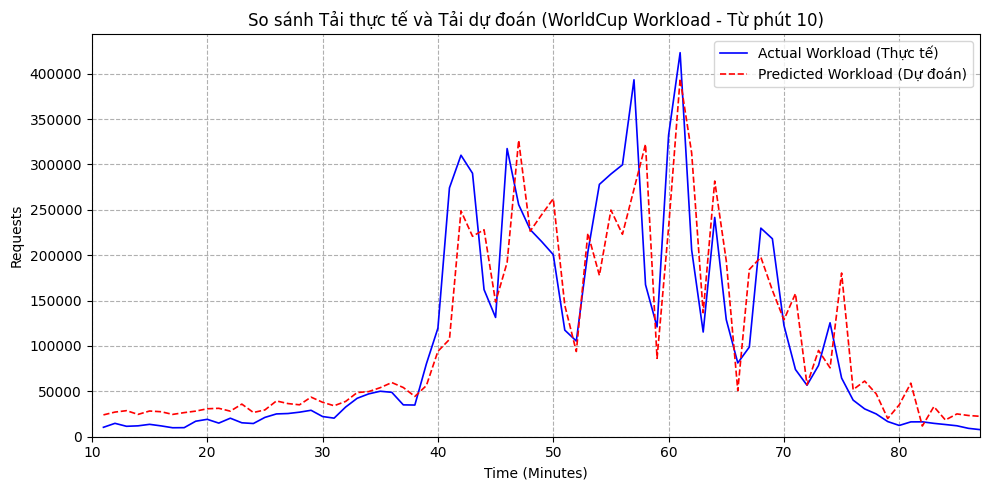

✅ Đã xuất biểu đồ Response Time & VMs count cho worldcup thành công!


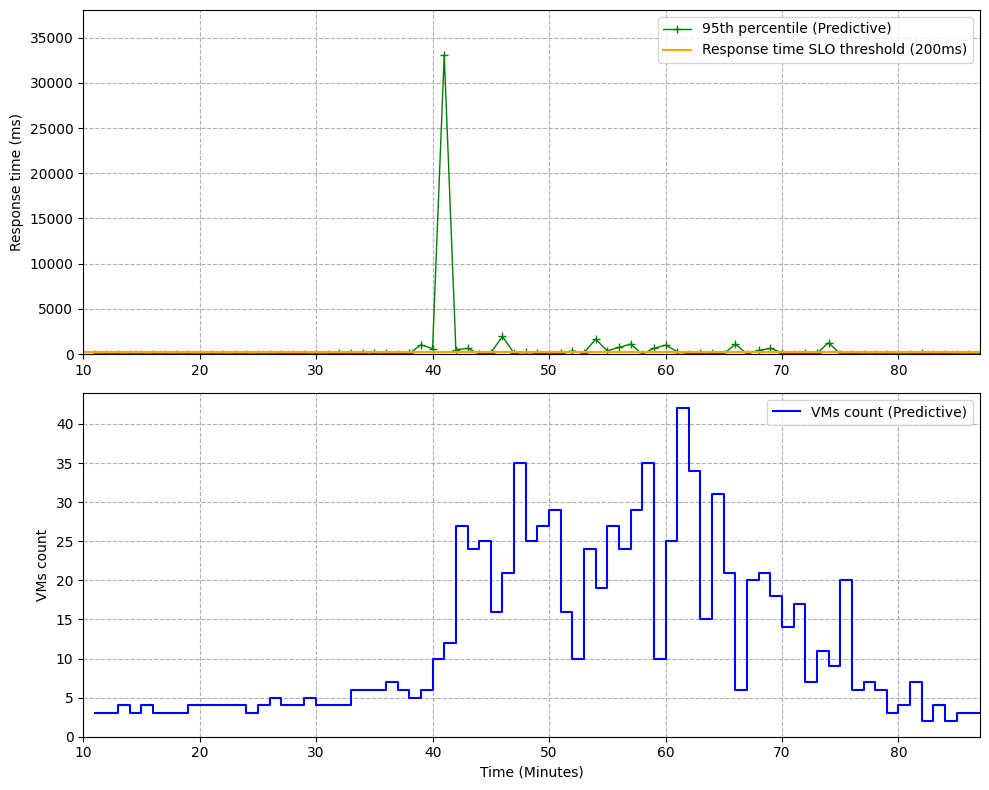

In [4]:
if original_df is not None:
# --- TÍNH TOÁN CHỈ SỐ TABLE I ---
    df_evaluation = df_predictive[df_predictive['minute'] > K_BEST]
    test_duration = len(df_evaluation)

    total_input_requests = df_evaluation['actual_requests'].sum()

    df_violations = df_evaluation[df_evaluation['response_time'] > TAU_SLO]
    total_slo_violations_requests = df_violations['actual_requests'].sum()

    total_processed_requests = total_input_requests - total_slo_violations_requests
    
    slo_violation_percentage = (total_slo_violations_requests / total_input_requests) * 100
    processed_requests_percentage = (total_processed_requests / total_input_requests) * 100

    print("\n" + "="*65)
    print(" 📊 BẢNG TỔNG KẾT CHỈ SỐ (TABLE I METRICS - WORLDCUP)")
    print("="*65)
    print(f" Tổng số phút kiểm thử          : {test_duration} phút")
    print(f" Tổng request đầu vào (Input)   : {total_input_requests:,} requests")
    print(f" Total Processed Requests       : {total_processed_requests:,} requests")
    print(f" Total SLO Violations           : {total_slo_violations_requests:,} requests")
    print(f" SLO Violation (%)              : {slo_violation_percentage:.2f}%")
    print(f" Processed Requests (%)         : {processed_requests_percentage:.2f}%")
    print("="*65)

    # --- 1. ĐỒ THỊ SO SÁNH TẢI THỰC TẾ VÀ TẢI DỰ ĐOÁN (TỪ K TRỞ ĐI) ---
    plt.figure(figsize=(10, 5))
    plt.plot(df_evaluation['minute'], df_evaluation['actual_requests'], color='blue', label='Actual Workload (Thực tế)', linewidth=1.2)
    plt.plot(df_evaluation['minute'], df_evaluation['predicted_requests'], color='red', linestyle='--', label='Predicted Workload (Dự đoán)', linewidth=1.2)

    # 1. Cố định chặt biên trái và biên phải của trục X
    max_minute = df_evaluation['minute'].max()
    plt.xlim(left=K_BEST, right=max_minute)

    # 2. Chủ động tạo các mốc ticks bắt đầu từ K_BEST (ví dụ mỗi 30 phút một mốc giống biểu đồ VM count)
    ticks = np.arange(K_BEST, max_minute + 1, 10)
    plt.xticks(ticks)  # Giới hạn trục X bắt đầu từ K_BEST

    plt.ylim(bottom=0)
    plt.ylabel('Requests')
    plt.xlabel('Time (Minutes)')
    plt.title(f'So sánh Tải thực tế và Tải dự đoán (WorldCup Workload - Từ phút {K_BEST})')
    plt.legend()
    plt.grid(True, linestyle='--')
    
    plt.tight_layout()
    plt.savefig("./data/workload_worldcup.png", dpi=300)
    print("✅ Đã xuất biểu đồ so sánh tải worldcup từ phút K thành công!")
    plt.show()

# --- 2. ĐỒ THỊ RESPONSE TIME VÀ VM COUNT (TỪ K TRỞ ĐI) ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
    max_rt_after_k = df_evaluation['response_time'].max()
    # Giới hạn trên trục Y sẽ lấy max thực tế nhân thêm khoảng 15% cho thoáng, nhưng phải đảm bảo ít nhất cao hơn đường ngưỡng SLO
    y_upper_limit = max(max_rt_after_k * 1.15, TAU_SLO * 1.25)
    max_minute = df_evaluation['minute'].max()

    ticks = np.arange(K_BEST, max_minute + 1, 10)

    ax1.plot(df_evaluation['minute'], df_evaluation['response_time'], color='green', marker='+', label='95th percentile (Predictive)', linewidth=1)
    ax1.axhline(y=TAU_SLO, color='orange', linestyle='-', label='Response time SLO threshold (200ms)')
    ax1.set_ylabel('Response time (ms)')
    # ax1.set_xlabel('Time (Minutes)')  # Có thể bật nhãn trục X cho đồ thị trên nếu muốn
    ax1.legend()
    ax1.grid(True, linestyle='--')

    ax1.set_xlim(left=K_BEST, right=max_minute)
    ax1.set_xticks(ticks)
    ax1.set_ylim(bottom=0,top=y_upper_limit)


    ax2.step(df_evaluation['minute'], df_evaluation['vms_count'], color='blue', where='post', label='VMs count (Predictive)')
    ax2.set_ylabel('VMs count')
    ax2.set_xlabel('Time (Minutes)')
    ax2.legend()
    ax2.grid(True, linestyle='--')
    ax2.set_xlim(left=K_BEST, right=max_minute)
    ax2.set_xticks(ticks)
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig("./data/predictive_worldcup.png", dpi=300)
    print("✅ Đã xuất biểu đồ Response Time & VMs count cho worldcup thành công!")
    plt.show()